# System Vulnerabilities Analysis of Network #
## Targeted Attack vs Random Failure ##

Install Packages

In [1]:
import pandas as pd 
import geopandas as gpd
%pip install matplotlib 
import matplotlib.pyplot as plt
import networkx as nx
%pip install seaborn
import seaborn as sns 
import numpy as np

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Read in Data

In [2]:
# Load node list from CSV
# Assuming the CSV has columns: 'node_id' and optionally other attributes
node_csv_path = "node_list_dc_btwn.csv"
nodes_df = pd.read_csv(node_csv_path)

# Load edge list from CSV
# Assuming the CSV has columns: 'source', 'target' and optionally other attributes
edge_csv_path = "edge_list.csv"
edges_df = pd.read_csv(edge_csv_path)

In [3]:
# Assuming your DataFrame is named 'df' and the column containing betweenness centrality is named 'betweenness_centrality'

# Find the maximum and minimum values
max_value = nodes_df['Betweenness Centrality'].max()
min_value = nodes_df['Betweenness Centrality'].min()
avg_value = nodes_df['Betweenness Centrality'].mean()

# Print the results
print(f"Maximum Betweenness Centrality: {max_value}")
print(f"Minimum Betweenness Centrality: {min_value}")
print(f"Average Betweenness Centrality: {avg_value}")

Maximum Betweenness Centrality: 222934938.11632985
Minimum Betweenness Centrality: 0.0
Average Betweenness Centrality: 1097383.6980646325


Build NetworkX Graph from NetworKit csv files

In [4]:
# Create an empty NetworkX graph
G = nx.Graph()

In [5]:
# Add nodes with attributes
for _, row in nodes_df.iterrows():
    node_id = row['Node ID']
    attributes = row.drop('Node ID').to_dict()  # Convert other columns to attributes
    G.add_node(node_id, **attributes)

# Add edges with attributes
for _, row in edges_df.iterrows():
    source = row['Source']
    target = row['Target']
    attributes = row.drop(['Source', 'Target']).to_dict()  # Convert other columns to attributes
    G.add_edge(source, target, **attributes)

# Verify the graph is created
print("Number of nodes in NetworkX graph:", G.number_of_nodes())
print("Number of edges in NetworkX graph:", G.number_of_edges())

Number of nodes in NetworkX graph: 23303
Number of edges in NetworkX graph: 34243


In [6]:
# Assuming 'G_sub_nx' is your NetworkX graph and betweenness centrality is already calculated as a node attribute

# Find the node with the maximum betweenness centrality
max_node = max(G.nodes, key=lambda node: G.nodes[node].get('Betweenness Centrality', 0))
max_value = G.nodes[max_node].get('Betweenness Centrality', 0)

# Print the results
print(f"Node with maximum betweenness centrality: {max_node}")
print(f"Maximum betweenness centrality value: {max_value}")

Node with maximum betweenness centrality: 16756.0
Maximum betweenness centrality value: 222934938.11632985


In [7]:
print(attributes.keys())

dict_keys(['Weight'])


In [8]:
# Convert DataFrame to a dictionary of dictionaries
attributes = nodes_df.set_index('Node ID').to_dict('index')

# Assign attributes to the graph
nx.set_node_attributes(G, attributes)

In [9]:
# Create a DataFrame from the NetworkX graph
nodes_df = pd.DataFrame(G.nodes(data=True), columns=['Node ID', 'Attributes'])
edges_df = pd.DataFrame(G.edges(data=True), columns=['Source', 'Target', 'Attributes'])

# Save the node and edge DataFrames to CSV
nodes_df.to_csv("nodes_nx.csv", index=False)
edges_df.to_csv("edges_nx.csv", index=False)

## Identify Largest Connected Component for Analysis

In [10]:
# Identify the largest connected component
largest_cc = max(nx.connected_components(G), key=len)

# Create a subgraph containing only the nodes in the largest connected component
G_sub_nx = G.subgraph(largest_cc).copy()  # Use `.copy()` to ensure it's a standalone graph

# Verify the node list remains the same
print("Number of nodes in NetworkX subgraph:", G_sub_nx.number_of_nodes())
print("Number of edges in NetworkX subgraph:", G_sub_nx.number_of_edges())

Number of nodes in NetworkX subgraph: 23298
Number of edges in NetworkX subgraph: 34239


Compare Metrics

In [11]:
print("Total Number of Edges in Network: ",G.number_of_edges())
print("Number of Edges in Subnetwork: ",G_sub_nx.number_of_edges())

Total Number of Edges in Network:  34243
Number of Edges in Subnetwork:  34239


In [12]:
print("Total Number of Nodes in Network: ",G.number_of_nodes())
print("Number of Nodes in Subnetwork: ",G_sub_nx.number_of_nodes())

Total Number of Nodes in Network:  23303
Number of Nodes in Subnetwork:  23298


In [13]:
print("Average degree of Network = ",2*G.number_of_edges()/G.number_of_nodes())
print("Average degree of Subnetwork = ",2*G_sub_nx.number_of_edges()/G_sub_nx.number_of_nodes())

Average degree of Network =  2.9389349010856973
Average degree of Subnetwork =  2.939222250836982


In [14]:
# Compute clustering coefficient
clustering_coeffs = nx.clustering(G_sub_nx)
min_clustering = min(clustering_coeffs.values())
max_clustering = max(clustering_coeffs.values())
print(f"Minimum clustering coefficient: {min_clustering}")
print(f"Maximum clustering coefficient: {max_clustering}")
print("Average Clustering Coefficient of Network = ", nx.average_clustering(G))
print("Average Clustering Coefficient of Subnetwork = ", nx.average_clustering(G_sub_nx))

Minimum clustering coefficient: 0
Maximum clustering coefficient: 1.0
Average Clustering Coefficient of Network =  0.019285377112695484
Average Clustering Coefficient of Subnetwork =  0.01928951596090406


In [15]:
# Compute degree
degrees = dict(G_sub_nx.degree())
min_degree = min(degrees.values())
max_degree = max(degrees.values())
print(f"Minimum degree: {min_degree}")
print(f"Maximum degree: {max_degree}")

Minimum degree: 1
Maximum degree: 8


In [ ]:
# Compute shortest path length
shortest_path_lengths = dict(nx.shortest_path_length(G_sub_nx))
all_lengths = [length for target_lengths in shortest_path_lengths.values() for length in target_lengths.values()]
min_shortest_path = min(all_lengths)
max_shortest_path = max(all_lengths)
print(f"Minimum shortest path length: {min_shortest_path}")
print(f"Maximum shortest path length: {max_shortest_path}")

In [ ]:
# Calculate the average shortest path length for the subgraph
avg_shortest_path_length = nx.average_shortest_path_length(G_sub_nx)
print("Average Shortest Path of Network =", avg_shortest_path_length)

Average Shortest Path of Network = 33.333333333333336


In [ ]:
# Assuming 'G_sub_nx' is your NetworkX graph and betweenness centrality is already calculated as a node attribute

# Find the node with the maximum betweenness centrality
max_node = max(G_sub_nx.nodes, key=lambda node: G_sub_nx.nodes[node].get('Betweenness Centrality', 0))
max_value = G_sub_nx.nodes[max_node].get('Betweenness Centrality', 0)

# Print the results
print(f"Node with maximum betweenness centrality: {max_node}")
print(f"Maximum betweenness centrality value: {max_value}")

Node with maximum betweenness centrality: 1225.0
Maximum betweenness centrality value: 180215.39727497488


In [ ]:
# Create a DataFrame from the subgraph
nodes_df_sub = pd.DataFrame(G_sub_nx.nodes(data=True), columns=['Node ID', 'Attributes'])
edges_df_sub = pd.DataFrame(G_sub_nx.edges(data=True), columns=['Source', 'Target', 'Attributes'])

# Save the subgraph node and edge DataFrames to CSV
nodes_df_sub.to_csv("nodes_nx_sub.csv", index=False)
edges_df_sub.to_csv("edges_nx_sub.csv", index=False)

# Targetted Attacks ##

Nodes sorted by Degree for Subnetwork

In [ ]:
N = G_sub_nx.number_of_nodes()
number_of_steps = N
M = N // number_of_steps

num_nodes_removed = range(0, N, M)
C = G_sub_nx.copy()
targeted_attack_core_proportions_d = []
fraction_nodes_removed = []
for nodes_removed in num_nodes_removed:
    # Measure the relative size of the network core
    core = max(nx.connected_components(C), key=len)

    core_proportion = len(core) / N
    targeted_attack_core_proportions_d.append(core_proportion)
    fraction_nodes_removed.append(nodes_removed / N)

    # If there are more than M nodes, select top M nodes and remove them
    if C.number_of_nodes() > M:
        nodes_sorted_by_degree = sorted(C.nodes, key=C.degree, reverse=True)
        nodes_to_remove = nodes_sorted_by_degree[:M]
        C.remove_nodes_from(nodes_to_remove)

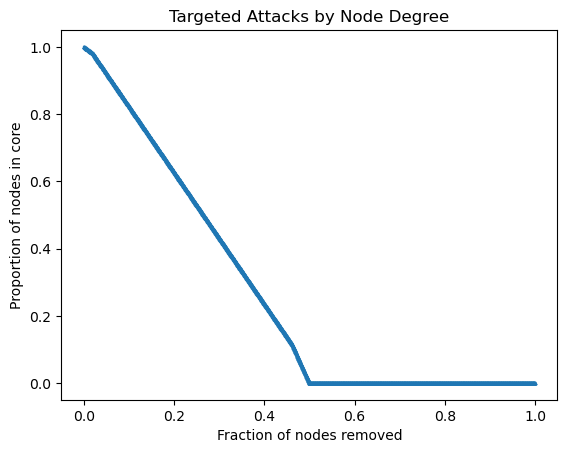

In [ ]:
plt.title('Targeted Attacks by Node Degree')
plt.xlabel('Fraction of nodes removed')
plt.ylabel('Proportion of nodes in core')
plt.plot(fraction_nodes_removed, targeted_attack_core_proportions_d, marker='^', markersize=2)

In [ ]:
# Save results to CSV file
results_deg_df = pd.DataFrame({
    'Fraction of Nodes Removed': fraction_nodes_removed,
    'Core Proportion': targeted_attack_core_proportions_d
})
results_deg_df.to_csv('TA-Degree.csv', index=False)

In [ ]:
# Print value of M
print("Value of M:", M)

Value of M: 1


In [ ]:
# Calculate the number of nodes removed in first 3 steps
num_nodes_removed_first_3_steps = 3 * M
print("Number of nodes removed in first 3 steps:", num_nodes_removed_first_3_steps)

Number of nodes removed in first 3 steps: 3


### Nodes sorted by Betweenness Centrality for Subnetwork ###
Static Prioritization: Betweenness Centrality ranked only at beginning, no dynamic updates

0 1.0
1 0.9996
2 0.9992
3 0.9988
4 0.9984
5 0.998
6 0.9976
7 0.9972
8 0.9968
9 0.9964
10 0.996
11 0.9956
12 0.9952
13 0.9948
14 0.9944
15 0.994
16 0.9936
17 0.9932
18 0.9928
19 0.9924
20 0.992
21 0.9916
22 0.9912
23 0.9908
24 0.9904
25 0.99
26 0.9896
27 0.9892
28 0.9888
29 0.9884
30 0.988
31 0.9876
32 0.9872
33 0.9868
34 0.9864
35 0.986
36 0.9856
37 0.9852
38 0.9848
39 0.9844
40 0.984
41 0.9836
42 0.9832
43 0.9828
44 0.9824
45 0.982
46 0.9816
47 0.9812
48 0.9808
49 0.9804
50 0.98
51 0.9796
52 0.9792
53 0.9788
54 0.9784
55 0.978
56 0.9776
57 0.9772
58 0.9768
59 0.9764
60 0.976
61 0.9756
62 0.9752
63 0.9748
64 0.9744
65 0.974
66 0.9736
67 0.9732
68 0.9728
69 0.9724
70 0.972
71 0.9716
72 0.9712
73 0.9708
74 0.9704
75 0.97
76 0.9696
77 0.9692
78 0.9688
79 0.9684
80 0.968
81 0.9676
82 0.9672
83 0.9668
84 0.9664
85 0.966
86 0.9656
87 0.9652
88 0.9648
89 0.9644
90 0.964
91 0.9636
92 0.9632
93 0.9628
94 0.9624
95 0.962
96 0.9616
97 0.9612
98 0.9608
99 0.9604
100 0.96
101 0.9596
102 0.9592
103 

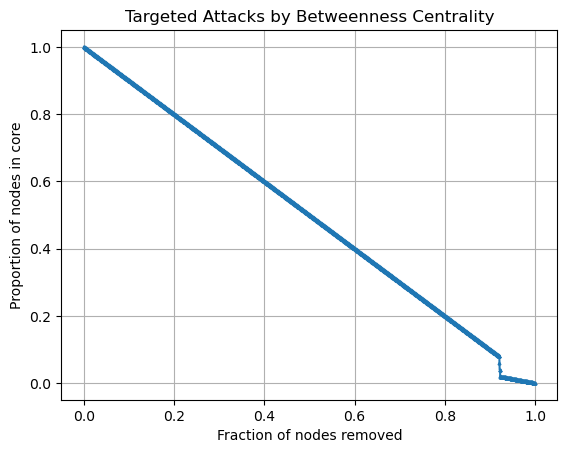

In [ ]:
# Adopted code from Marta
# Assuming betweenness centrality values are stored in the `attributes` dictionary
N = G_sub_nx.number_of_nodes()
number_of_steps = N
M = N // number_of_steps

num_nodes_removed = range(0, N, M)
C = G_sub_nx.copy()
targeted_attack_core_proportions_btwn = []
fraction_nodes_removed = []

############# Check the copy
# Convert nodes to DataFrame
nodes_df_sub = pd.DataFrame(C.nodes(data=True), columns=['Node ID', 'Attributes'])

# Expand attribute dictionary into separate columns
nodes_df_sub = nodes_df_sub.join(pd.json_normalize(nodes_df_sub.pop("Attributes")))

# Sort by "Betweenness Centrality" in descending order
nodes_df_sub = nodes_df_sub.sort_values(by="Betweenness Centrality", ascending=False)

# Save to CSV
nodes_df_sub.to_csv("copy_nodes_nx_sub.csv", index=False)

# Convert edges to DataFrame (unchanged)
edges_df_sub = pd.DataFrame(C.edges(data=True), columns=['Source', 'Target', 'Attributes'])
edges_df_sub = edges_df_sub.join(pd.json_normalize(edges_df_sub.pop("Attributes")))
edges_df_sub.to_csv("copy_edges_nx_sub.csv", index=False)

for nodes_removed in num_nodes_removed:
    # Measure the relative size of the network core
    core = max(nx.connected_components(C), key=len)
    core_proportion = len(core) / N

    # Save the largest connected component (core) nodes and edges to CSV
    C_core = C.subgraph(core).copy()  # Create a subgraph of the largest connected component

    # Save core nodes to CSV
    core_nodes_df = pd.DataFrame(C_core.nodes(data=True), columns=['Node ID', 'Attributes'])
    core_nodes_df = core_nodes_df.join(pd.json_normalize(core_nodes_df.pop("Attributes")))

    # Calculate log of betweenness centrality
    if 'Betweenness Centrality' in core_nodes_df.columns:
        core_nodes_df['Log Betweenness Centrality'] = np.log(core_nodes_df['Betweenness Centrality'].replace(0, np.nan))

    core_nodes_df.to_csv(f"TA_Core_Nodes/core_nodes_{nodes_removed}.csv", index=False)

    # Save core edges to CSV
    core_edges_df = pd.DataFrame(C_core.edges(data=True), columns=['Source', 'Target', 'Attributes'])
    core_edges_df = core_edges_df.join(pd.json_normalize(core_edges_df.pop("Attributes")))
    core_edges_df.to_csv(f"TA_Core_Edges/core_edges_{nodes_removed}.csv", index=False)

    targeted_attack_core_proportions_btwn.append(core_proportion)
    fraction_nodes_removed.append(nodes_removed / N)
    print(nodes_removed,core_proportion)

    # If there are more than M nodes, select top M nodes by betweenness centrality and remove them
    if C.number_of_nodes() > M:
        # Ensure node IDs match the keys in the attributes dictionary
        nodes_sorted_by_betweenness = sorted(
            C.nodes, 
            key=lambda node: attributes[int(node)]['Betweenness Centrality'],  # Convert node ID to int if necessary
            reverse=True
        )
        nodes_to_remove = nodes_sorted_by_betweenness[:M]
        C.remove_nodes_from(nodes_to_remove)        

    # Save removed nodes and their attributes to a csv file
        removed_nodes_data = []
        # Create a DataFrame with Node ID, Betweenness Centrality, Coordinates, and Step
        for node in nodes_to_remove:
            removed_nodes_data.append({
                "Node ID": node,
                "Betweenness Centrality": attributes[int(node)]['Betweenness Centrality'],
                "Longitude": attributes[int(node)]['Longitude'],
                "Latitude": attributes[int(node)]['Latitude'],
                "Step": nodes_removed
            })
        removed_nodes_df = pd.DataFrame(removed_nodes_data)
        removed_nodes_df.to_csv(f"TargetAttack_Removal/TA_removed_nodes_{nodes_removed}.csv", index=False)

# Save the results to a CSV file
results_btwn_df = pd.DataFrame({
    'Fraction of Nodes Removed': fraction_nodes_removed,
    'Core Proportion': targeted_attack_core_proportions_btwn
})
results_btwn_df.to_csv('TA-BC-Static.csv', index=False)

# Plotting the results
plt.title('Targeted Attacks by Betweenness Centrality')
plt.xlabel('Fraction of nodes removed')
plt.ylabel('Proportion of nodes in core')
plt.plot(fraction_nodes_removed, targeted_attack_core_proportions_btwn, marker='^', markersize=2)
plt.grid(True)
plt.show()

In [ ]:
# Check the top 10 nodes by betweenness centrality in subgraph G_sub_nx
top_10_nodes = sorted(G_sub_nx.nodes, key=lambda node: G_sub_nx.nodes[node].get('Betweenness Centrality', 0), reverse=True)[:10]
print("Top 10 nodes by betweenness centrality in subgraph G_sub_nx:")
for node in top_10_nodes:
    print(f"Node ID: {node}, Betweenness Centrality: {G_sub_nx.nodes[node].get('Betweenness Centrality', 0)}")

Top 10 nodes by betweenness centrality in subgraph G_sub_nx:
Node ID: 1225.0, Betweenness Centrality: 180215.39727497488
Node ID: 1224.0, Betweenness Centrality: 180215.3972749748
Node ID: 1274.0, Betweenness Centrality: 180215.3972749744
Node ID: 1275.0, Betweenness Centrality: 180215.3972749742
Node ID: 1226.0, Betweenness Centrality: 179521.97396376077
Node ID: 1223.0, Betweenness Centrality: 179521.97396376068
Node ID: 1325.0, Betweenness Centrality: 179521.97396376065
Node ID: 1324.0, Betweenness Centrality: 179521.9739637606
Node ID: 1273.0, Betweenness Centrality: 179521.97396376045
Node ID: 1175.0, Betweenness Centrality: 179521.97396376033


In [ ]:
# Check the top 10 nodes by betweenness centrality in subgraph C_core
top_10_nodes = sorted(C_core.nodes, key=lambda node: C_core.nodes[node].get('Betweenness Centrality', 0), reverse=True)[:10]
print("Top 10 nodes by betweenness centrality in subgraph C_core:")
for node in top_10_nodes:
    print(f"Node ID: {node}, Betweenness Centrality: {C_core.nodes[node].get('Betweenness Centrality', 0)}")

Top 10 nodes by betweenness centrality in subgraph C_core:
Node ID: 2499.0, Betweenness Centrality: 15.835188700256468


In [ ]:
# Check the top 10 nodes by betweenness centrality in graph C
top_10_nodes = sorted(C.nodes, key=lambda node: C.nodes[node].get('Betweenness Centrality', 0), reverse=True)[:10]
print("Top 10 nodes by betweenness centrality in graph C:")
for node in top_10_nodes:
    print(f"Node ID: {node}, Betweenness Centrality: {C.nodes[node].get('Betweenness Centrality', 0)}")

Top 10 nodes by betweenness centrality in graph C:
Node ID: 2499.0, Betweenness Centrality: 15.835188700256468


### Nodes sorted by Betweenness Centrality for Subnetwork ###
Dynamic Prioritization: Betweenness Centrality Recomputed after Each Node Removal Step

0 1.0
1 0.9996
2 0.9992
3 0.9988
4 0.9984
5 0.998
6 0.9976
7 0.9972
8 0.9968
9 0.9964
10 0.996
11 0.9956
12 0.9952
13 0.9948
14 0.9944
15 0.994
16 0.9936
17 0.9932
18 0.9928
19 0.9924
20 0.992
21 0.9916
22 0.9912
23 0.9908
24 0.9904
25 0.99
26 0.9896
27 0.9892
28 0.9888
29 0.9884
30 0.988
31 0.9876
32 0.9872
33 0.9868
34 0.9864
35 0.986
36 0.9856
37 0.9852
38 0.9848
39 0.9844
40 0.984
41 0.9836
42 0.9832
43 0.9828
44 0.9824
45 0.982
46 0.9816
47 0.9812
48 0.9808
49 0.9804
50 0.5076
51 0.5072
52 0.5068
53 0.5064
54 0.506
55 0.5056
56 0.5052
57 0.5048
58 0.5044
59 0.504
60 0.5036
61 0.5032
62 0.5028
63 0.5024
64 0.502
65 0.5016
66 0.5012
67 0.5008
68 0.5004
69 0.5
70 0.4996
71 0.4992
72 0.4988
73 0.4984
74 0.4724
75 0.472
76 0.4716
77 0.4712
78 0.4708
79 0.4704
80 0.47
81 0.4696
82 0.4692
83 0.4688
84 0.4684
85 0.468
86 0.4676
87 0.4672
88 0.4668
89 0.4664
90 0.466
91 0.4656
92 0.4652
93 0.4648
94 0.4644
95 0.464
96 0.4636
97 0.4632
98 0.2584
99 0.258
100 0.2576
101 0.2572
102 0.2568
103

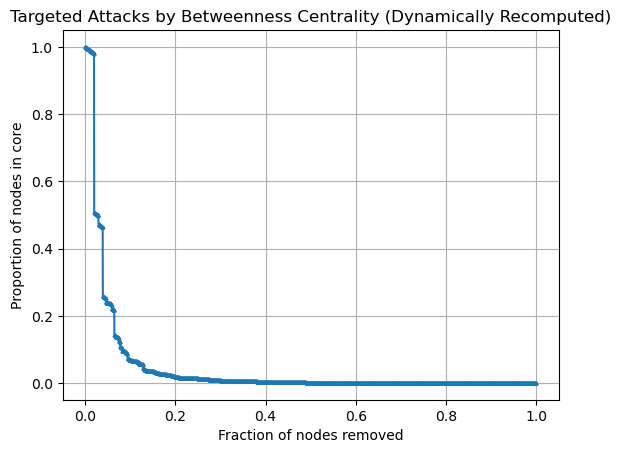

In [ ]:
# Adopted code from Marta
# Recompute betweenness centrality of remaining largest connected component after each node removal
N = G_sub_nx.number_of_nodes()
number_of_steps = N
M = N // number_of_steps

num_nodes_removed = range(0, N, M)
C = G_sub_nx.copy()
targeted_attack_core_proportions_btwn_dyn = []
fraction_nodes_removed = []

############# Check the copy
# Convert nodes to DataFrame
nodes_df_sub = pd.DataFrame(C.nodes(data=True), columns=['Node ID', 'Attributes'])

# Expand attribute dictionary into separate columns
nodes_df_sub = nodes_df_sub.join(pd.json_normalize(nodes_df_sub.pop("Attributes")))

# Sort by "Betweenness Centrality" in descending order
nodes_df_sub = nodes_df_sub.sort_values(by="Betweenness Centrality", ascending=False)

# Save to CSV
nodes_df_sub.to_csv("copy_nodes_nx_sub_dyn.csv", index=False)

# Convert edges to DataFrame (unchanged)
edges_df_sub = pd.DataFrame(C.edges(data=True), columns=['Source', 'Target', 'Attributes'])
edges_df_sub = edges_df_sub.join(pd.json_normalize(edges_df_sub.pop("Attributes")))
edges_df_sub.to_csv("copy_edges_nx_sub_dyn.csv", index=False)

for nodes_removed in num_nodes_removed:
    # Measure the relative size of the network core
    core = max(nx.connected_components(C), key=len)
    core_proportion = len(core) / N

    # Save the largest connected component (core) nodes and edges to CSV
    C_core = C.subgraph(core).copy()  # Create a subgraph of the largest connected component

    # Save core nodes to CSV
    core_nodes_df = pd.DataFrame(C_core.nodes(data=True), columns=['Node ID', 'Attributes'])
    core_nodes_df = core_nodes_df.join(pd.json_normalize(core_nodes_df.pop("Attributes")))

    # Calculate log of betweenness centrality
    if 'Betweenness Centrality' in core_nodes_df.columns:
        core_nodes_df['Log Betweenness Centrality'] = np.log(core_nodes_df['Betweenness Centrality'].replace(0, np.nan))

    core_nodes_df.to_csv(f"TA_Core_Nodes-Dynamic/core_nodes_{nodes_removed}.csv", index=False)

    # Save core edges to CSV
    core_edges_df = pd.DataFrame(C_core.edges(data=True), columns=['Source', 'Target', 'Attributes'])
    core_edges_df = core_edges_df.join(pd.json_normalize(core_edges_df.pop("Attributes")))
    core_edges_df.to_csv(f"TA_Core_Edges-Dynamic/core_edges_{nodes_removed}.csv", index=False)

    targeted_attack_core_proportions_btwn_dyn.append(core_proportion)
    fraction_nodes_removed.append(nodes_removed / N)
    print(nodes_removed,core_proportion)

    # If there are more than M nodes, recompute betweenness centrality and select top M nodes to remove
    if C.number_of_nodes() > M:
        # Recompute betweenness centrality for the current graph
        current_bc = nx.betweenness_centrality(C)
        
        # Get nodes sorted by updated betweenness centrality in descending order
        nodes_sorted_by_betweenness = sorted(
            C.nodes, 
            key=lambda node: current_bc[node],
            reverse=True
        )
        nodes_to_remove = nodes_sorted_by_betweenness[:M]
        C.remove_nodes_from(nodes_to_remove)        

    # Save removed nodes and their attributes to a csv file
        removed_nodes_data = []
        # Create a DataFrame with Node ID, Betweenness Centrality, Coordinates, and Step
        for node in nodes_to_remove:
            removed_nodes_data.append({
                "Node ID": node,
                "Betweenness Centrality": current_bc[node],
                "Longitude": attributes[int(node)]['Longitude'],
                "Latitude": attributes[int(node)]['Latitude'],
                "Step": nodes_removed
            })
        removed_nodes_df = pd.DataFrame(removed_nodes_data)
        removed_nodes_df.to_csv(f"TargetAttack_Removal-Dynamic/TA_removed_nodes_{nodes_removed}.csv", index=False)

# Save the results to a CSV file
results_btwn_dyn_df = pd.DataFrame({
    'Fraction of Nodes Removed': fraction_nodes_removed,
    'Core Proportion': targeted_attack_core_proportions_btwn_dyn
})
results_btwn_dyn_df.to_csv('TA-BC-Dynamic.csv', index=False)

# Plotting the results
plt.title('Targeted Attacks by Betweenness Centrality (Dynamically Recomputed)')
plt.xlabel('Fraction of nodes removed')
plt.ylabel('Proportion of nodes in core')
plt.plot(fraction_nodes_removed, targeted_attack_core_proportions_btwn_dyn, marker='^', markersize=2)
plt.grid(True)
plt.show()

## Random Attack

In [ ]:
import random

In [ ]:
# Adopt code from Marta

N = G_sub_nx.number_of_nodes()
number_of_steps = N
M = N // number_of_steps

num_nodes_removed = range(0, N, M)
C = G_sub_nx.copy()

print(M)

random_attack_core_proportions = []
fraction_nodes_removed = []
for nodes_removed in num_nodes_removed:
    # Measure the relative size of the network core
    core = max(nx.connected_components(C), key=len)
    core_proportion = len(core) / N
    
    # Save the largest connected component (core) nodes and edges to CSV
    C_core = C.subgraph(core).copy()  # Create a subgraph of the largest connected component

    # Save core nodes to CSV
    core_nodes_df = pd.DataFrame(C_core.nodes(data=True), columns=['Node ID', 'Attributes'])
    core_nodes_df = core_nodes_df.join(pd.json_normalize(core_nodes_df.pop("Attributes")))
    core_nodes_df.to_csv(f"RA_Core_Nodes/RA_core_nodes_{nodes_removed}.csv", index=False)

    # Save core edges to CSV
    core_edges_df = pd.DataFrame(C_core.edges(data=True), columns=['Source', 'Target', 'Attributes'])
    core_edges_df = core_edges_df.join(pd.json_normalize(core_edges_df.pop("Attributes")))
    core_edges_df.to_csv(f"RA_Core_Edges/RA_core_edges_{nodes_removed}.csv", index=False)

    random_attack_core_proportions.append(core_proportion)
    fraction_nodes_removed.append(nodes_removed / N)
    print(nodes_removed,core_proportion)

    # If there are more than M nodes, select M nodes at random and remove them
    if C.number_of_nodes() > M:
        nodes_to_remove = random.sample(list(C.nodes), M)
        C.remove_nodes_from(nodes_to_remove)

    # Save removed nodes and their attributes to a csv file
        removed_nodes_data = []
        # Create a DataFrame with Node ID, Betweenness Centrality, Coordinates, and Step
        for node in nodes_to_remove:
            removed_nodes_data.append({
                "Node ID": node,
                "Betweenness Centrality": attributes[int(node)]['Betweenness Centrality'],
                "Longitude": attributes[int(node)]['Longitude'],
                "Latitude": attributes[int(node)]['Latitude'],
                "Step": nodes_removed
            })
        removed_nodes_df = pd.DataFrame(removed_nodes_data)
        removed_nodes_df.to_csv(f"RandomAttack_Removal/RA_removed_nodes_{nodes_removed}.csv", index=False)



1
0 1.0
1 0.9996
2 0.9992
3 0.9988
4 0.9984
5 0.998
6 0.9976
7 0.9972
8 0.9968
9 0.9964
10 0.996
11 0.9956
12 0.9952
13 0.9948
14 0.9944
15 0.994
16 0.9936
17 0.9932
18 0.9928
19 0.9924
20 0.992
21 0.9916
22 0.9912
23 0.9908
24 0.9904
25 0.99
26 0.9896
27 0.9892
28 0.9888
29 0.9884
30 0.988
31 0.9876
32 0.9872
33 0.9868
34 0.9864
35 0.986
36 0.9856
37 0.9852
38 0.9848
39 0.9844
40 0.984
41 0.9836
42 0.9832
43 0.9828
44 0.9824
45 0.982
46 0.9816
47 0.9812
48 0.9808
49 0.9804
50 0.98
51 0.9796
52 0.9792
53 0.9788
54 0.9784
55 0.978
56 0.9776
57 0.9772
58 0.9768
59 0.9764
60 0.976
61 0.9756
62 0.9752
63 0.9748
64 0.9744
65 0.974
66 0.9736
67 0.9732
68 0.9728
69 0.9724
70 0.972
71 0.9716
72 0.9712
73 0.9708
74 0.9704
75 0.97
76 0.9696
77 0.9692
78 0.9688
79 0.9684
80 0.968
81 0.9676
82 0.9672
83 0.9668
84 0.9664
85 0.966
86 0.9656
87 0.9652
88 0.9648
89 0.9644
90 0.964
91 0.9636
92 0.9632
93 0.9628
94 0.9624
95 0.962
96 0.9616
97 0.9612
98 0.9608
99 0.9604
100 0.96
101 0.9596
102 0.9592
10

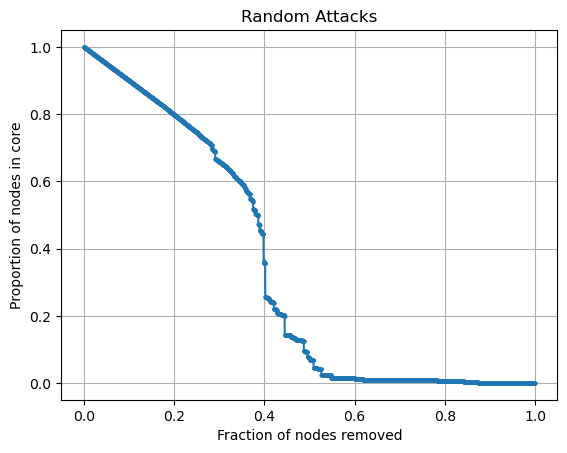

In [ ]:
# Plot Random Attack results
plt.title('Random Attacks')
plt.xlabel('Fraction of nodes removed')
plt.ylabel('Proportion of nodes in core')
plt.plot(fraction_nodes_removed, random_attack_core_proportions, marker='o', markersize=2)
plt.grid(True)
plt.show()

In [ ]:
# Repeated Random Attack for confidence interval

N = G_sub_nx.number_of_nodes()
number_of_steps = N
M = N // number_of_steps

num_nodes_removed = range(0, G_sub_nx.number_of_nodes(), M)

# Run random attack 10 times
num_runs = 10
all_random_attack_runs = []
fraction_nodes_removed = []

for run in range(num_runs):
    C = G_sub_nx.copy()
    random_attack_core_proportions = []
    
    for nodes_removed in num_nodes_removed:
        # Measure the relative size of the network core
        core = max(nx.connected_components(C), key=len)
        core_proportion = len(core) / N
        random_attack_core_proportions.append(core_proportion)
        
        # Only add to fraction_nodes_removed once (same for all runs)
        if run == 0:
            fraction_nodes_removed.append(nodes_removed / N)

        # If there are more than M nodes, select M nodes at random and remove them
        if C.number_of_nodes() > M:
            nodes_to_remove = random.sample(list(C.nodes), M)
            C.remove_nodes_from(nodes_to_remove)
    
    all_random_attack_runs.append(random_attack_core_proportions)

# Calculate mean and standard deviation across all runs
random_attack_core_proportions_mean = np.mean(all_random_attack_runs, axis=0)
random_attack_core_proportions_std = np.std(all_random_attack_runs, axis=0)

print(f"Completed {num_runs} random attack simulations")
print(f"Mean core proportion: {random_attack_core_proportions_mean}")


Completed 10 random attack simulations
Mean core proportion: [1.000e+00 9.996e-01 9.992e-01 ... 4.000e-04 4.000e-04 4.000e-04]


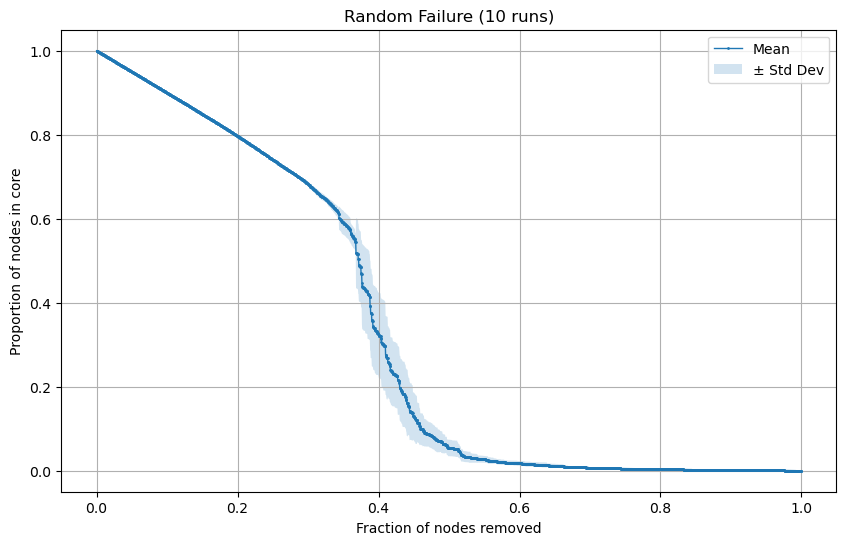

In [ ]:
plt.figure(figsize=(10, 6))
plt.title('Random Failure (10 runs)')
plt.xlabel('Fraction of nodes removed')
plt.ylabel('Proportion of nodes in core')
plt.plot(fraction_nodes_removed, random_attack_core_proportions_mean, marker='o', label='Mean', markersize=1, linewidth=1)
plt.fill_between(fraction_nodes_removed, 
                 random_attack_core_proportions_mean - random_attack_core_proportions_std,
                 random_attack_core_proportions_mean + random_attack_core_proportions_std,
                 alpha=0.2, label='± Std Dev')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Save plot data to CSV
random_attack_results_df = pd.DataFrame({
    'Fraction of Nodes Removed': fraction_nodes_removed,
    'Mean Core Proportion': random_attack_core_proportions_mean,
    'Std Dev Core Proportion': random_attack_core_proportions_std
})
random_attack_results_df.to_csv('RA-Results.csv', index=False)

## Plot Comparisons ##

In [ ]:
# Truncate to match lengths
min_length = min(len(targeted_attack_core_proportions_btwn), len(targeted_attack_core_proportions_d), len(random_attack_core_proportions_mean), len(targeted_attack_core_proportions_btwn_dyn))
random_attack_mean_trim = random_attack_core_proportions_mean[:min_length]
targeted_attack_btwn_trim = targeted_attack_core_proportions_btwn[:min_length]
targeted_attack_deg_trim = targeted_attack_core_proportions_d[:min_length]
targeted_attack_btwn_dyn_trim = targeted_attack_core_proportions_btwn_dyn[:min_length]

Targeted Attack by Betweenness Centrality vs Random 

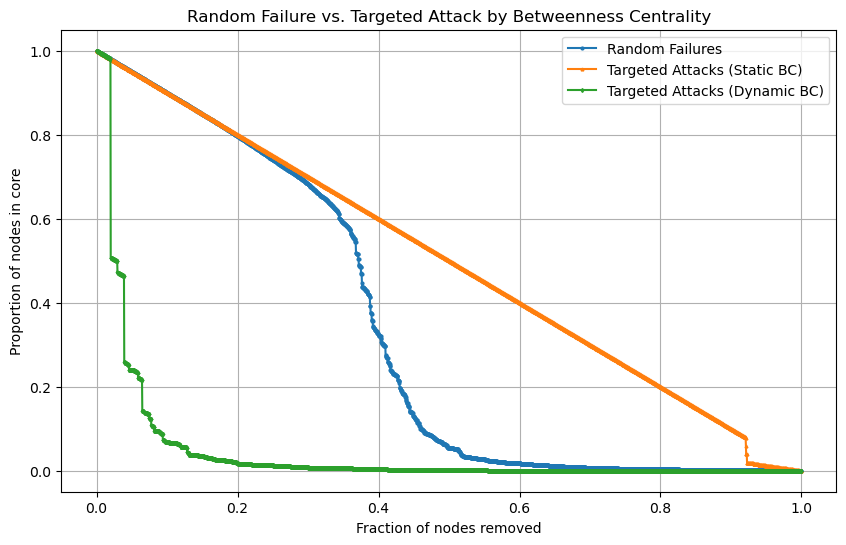

In [ ]:
plt.figure(figsize=(10, 6))
plt.xlabel('Fraction of nodes removed')
plt.ylabel('Proportion of nodes in core')
plt.title('Random Failure vs. Targeted Attack by Betweenness Centrality')
plt.plot(fraction_nodes_removed, random_attack_mean_trim, marker='o', label='Random Failures', markersize=2)
plt.plot(fraction_nodes_removed, targeted_attack_btwn_trim, marker='^', label='Targeted Attacks (Static BC)', markersize=2)
plt.plot(fraction_nodes_removed, targeted_attack_btwn_dyn_trim, marker='d', label='Targeted Attacks (Dynamic BC)', markersize=2)
plt.grid(True)
plt.legend()
plt.show()

Targeted Attack by Degree vs Random Failure

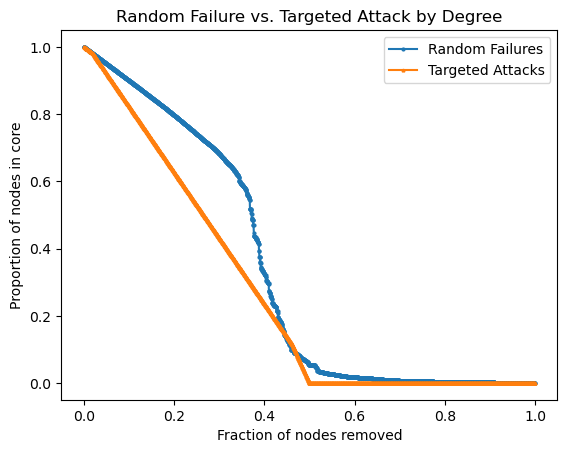

In [ ]:
plt.xlabel('Fraction of nodes removed')
plt.ylabel('Proportion of nodes in core')
plt.title('Random Failure vs. Targeted Attack by Degree')
plt.plot(fraction_nodes_removed, random_attack_mean_trim, marker='o', label='Random Failures', markersize=2)
plt.plot(fraction_nodes_removed, targeted_attack_deg_trim, marker='^', label='Targeted Attacks', markersize=2)
plt.legend()

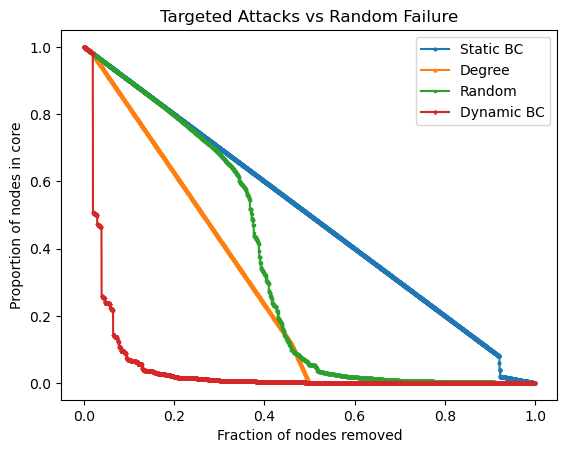

In [ ]:
# Plot all attacks
plt.xlabel('Fraction of nodes removed')
plt.ylabel('Proportion of nodes in core')
plt.title('Targeted Attacks vs Random Failure')
plt.plot(fraction_nodes_removed, targeted_attack_btwn_trim, marker='o', label='Static BC', markersize=2)
plt.plot(fraction_nodes_removed, targeted_attack_deg_trim, marker='^', label='Degree', markersize=2)
plt.plot(fraction_nodes_removed, random_attack_mean_trim, marker='s', label='Random', markersize=2)
plt.plot(fraction_nodes_removed, targeted_attack_btwn_dyn_trim, marker='d', label='Dynamic BC', markersize=2)
plt.legend()